In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

In [2]:
df = pd.read_csv("train-labels.csv")

#Considering only 6 size ones cuz 2 samples are anomalous
df = df[df["text"].str.len() == 6].copy()

print(df.shape)
df.head()

(19998, 3)


,Unnamed: 0,image,text
0,0,train-0.png,BU522X
1,1,train-1.png,XQ8NE2
2,2,train-2.png,DTZD3E
3,3,train-3.png,SM424H
4,4,train-4.png,6YVTQR


In [3]:
characters = sorted(set("".join(df["text"])))

print(characters)
print("Vocabulary Size:", len(characters))

['2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Vocabulary Size: 31


In [4]:
char_to_num = {
    char: idx
    for idx, char in enumerate(characters)
}

num_to_char = {
    idx: char
    for idx, char in enumerate(characters)
}

In [5]:
for i, value in enumerate(characters):
    print(i, value)

0 2
1 3
2 4
3 5
4 6
5 7
6 8
7 9
8 A
9 B
10 C
11 D
12 E
13 F
14 G
15 H
16 J
17 K
18 M
19 N
20 P
21 Q
22 R
23 S
24 T
25 U
26 V
27 W
28 X
29 Y
30 Z


In [6]:
sample_text = df.iloc[0]["text"]

encoded = [char_to_num[c] for c in sample_text]

decoded = "".join(
    num_to_char[i]
    for i in encoded
)

print("Original:", sample_text)
print("Encoded:", encoded)
print("Decoded:", decoded)

Original: BU522X
Encoded: [9, 25, 3, 0, 0, 28]
Decoded: BU522X


In [7]:
def preprocess_image(path):

    img = cv2.imread(
        path,
        cv2.IMREAD_GRAYSCALE
    )

    img = img.astype(np.float32)

    img = img / 255.0

    img = np.expand_dims(
        img,
        axis=-1
    )

    return img

In [8]:
sample_image = "train_images/train-0.png"

img = preprocess_image(sample_image)

print(img.shape)
print(img.dtype)
print(img.min())
print(img.max())

(100, 200, 1)
float32
0.0
0.9411765


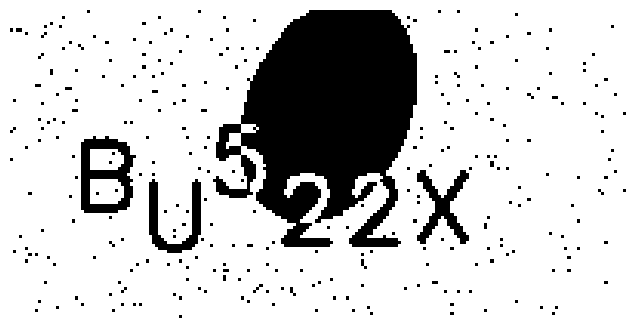

In [9]:
plt.figure(figsize=(8,4))

plt.imshow(
    img.squeeze(),
    cmap="gray"
)

plt.axis("off")

plt.show()

In [10]:
def encode_label(text):

    return np.array(
        [char_to_num[c] for c in text],
        dtype=np.int32
    )

In [11]:
sample_label = df.iloc[0]["text"]

encoded = encode_label(sample_label)

print(sample_label)
print(encoded)

BU522X
[ 9 25  3  0  0 28]


In [12]:
def decode_label(encoded):

    return "".join(
        num_to_char[int(i)]
        for i in encoded
    )

In [13]:
decoded = decode_label(encoded)

print(decoded)

BU522X


In [14]:
row = df.iloc[0]

image_path = (
    "train_images/" +
    row["image"]
)

image = preprocess_image(
    image_path
)

label = encode_label(
    row["text"]
)

print("Image Shape:", image.shape)

print("Label:", label)

Image Shape: (100, 200, 1)
Label: [ 9 25  3  0  0 28]


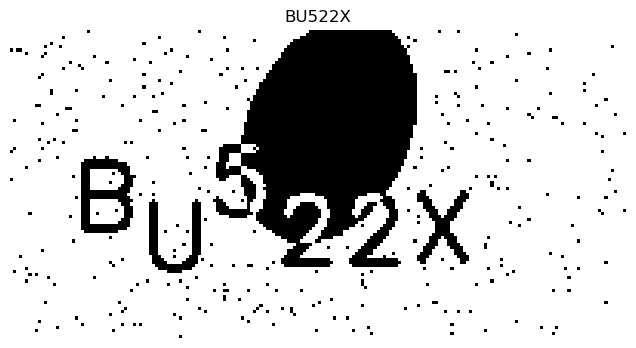

In [15]:
plt.figure(figsize=(8,4))

plt.imshow(
    image.squeeze(),
    cmap="gray"
)

plt.title(row["text"])

plt.axis("off")

plt.show()